In [ ]:
#Importo herramientas
# Para manipulación de datos
import pandas as pd
import numpy as np

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
!pip install shap
import shap

# Para preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay

# Para modelado RL, SVM
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC

# Para modelado LR, KNN, NB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Para modelos tipo Random Forest
from statsmodels.datasets import get_rdataset
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Para evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score, recall_score, precision_score, mean_squared_error, r2_score


# Configuraciones adicionales para una mejor visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
# Ignorar warnings para una salida más limpia (opcional)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Importo el df
df = pd.read_csv("StressLevelDataset.csv")
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2


In [ ]:
#Reviso la informacion de los tipos de variables con las que estoy tratando, cantidad, filas y columans
df.info()
print(f"\n filas y columnas: {df.shape}")
#Cuales son las features
print(f"\n filas y columnas: {df.columns}")
#Realizo un diccionario con las columnas (features y sus respectivos valores)
diccionario_valores = {columna: df[columna].unique().tolist() for columna in df.columns}
print(f"\n filas y columnas: {diccionario_valores} ")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

la cantidad de faltantes:
 anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


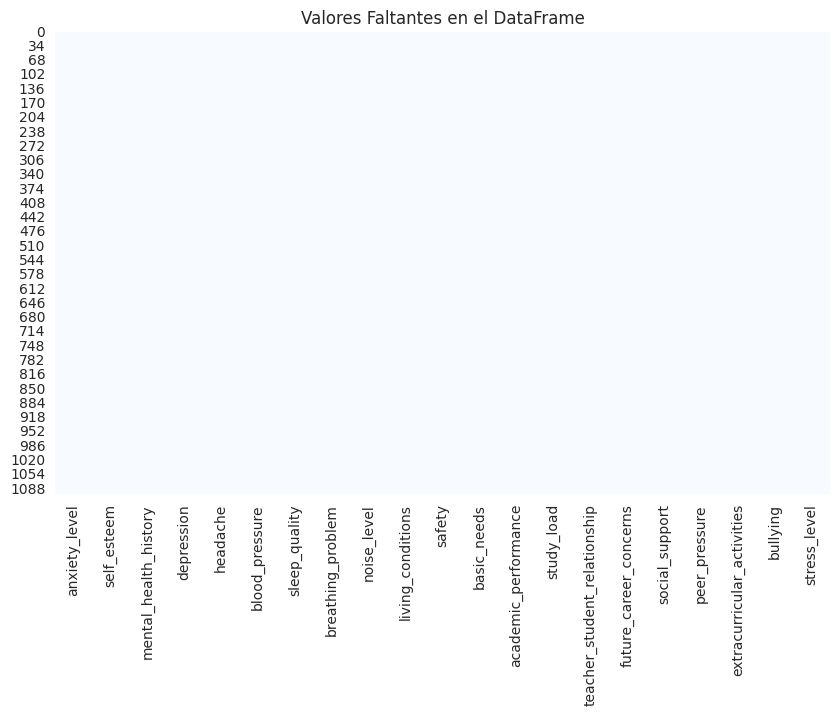

In [ ]:
#Analizo si hay datos vacios
print(f"la cantidad de faltantes:\n {df.isnull().sum()}")
#Grafico un heat map apra visualizar los faltantes
sns.heatmap(df.isnull(), cbar=False, cmap= 'Blues')
plt.title('Valores Faltantes en el DataFrame')
plt.show()

El df se encuentra completo

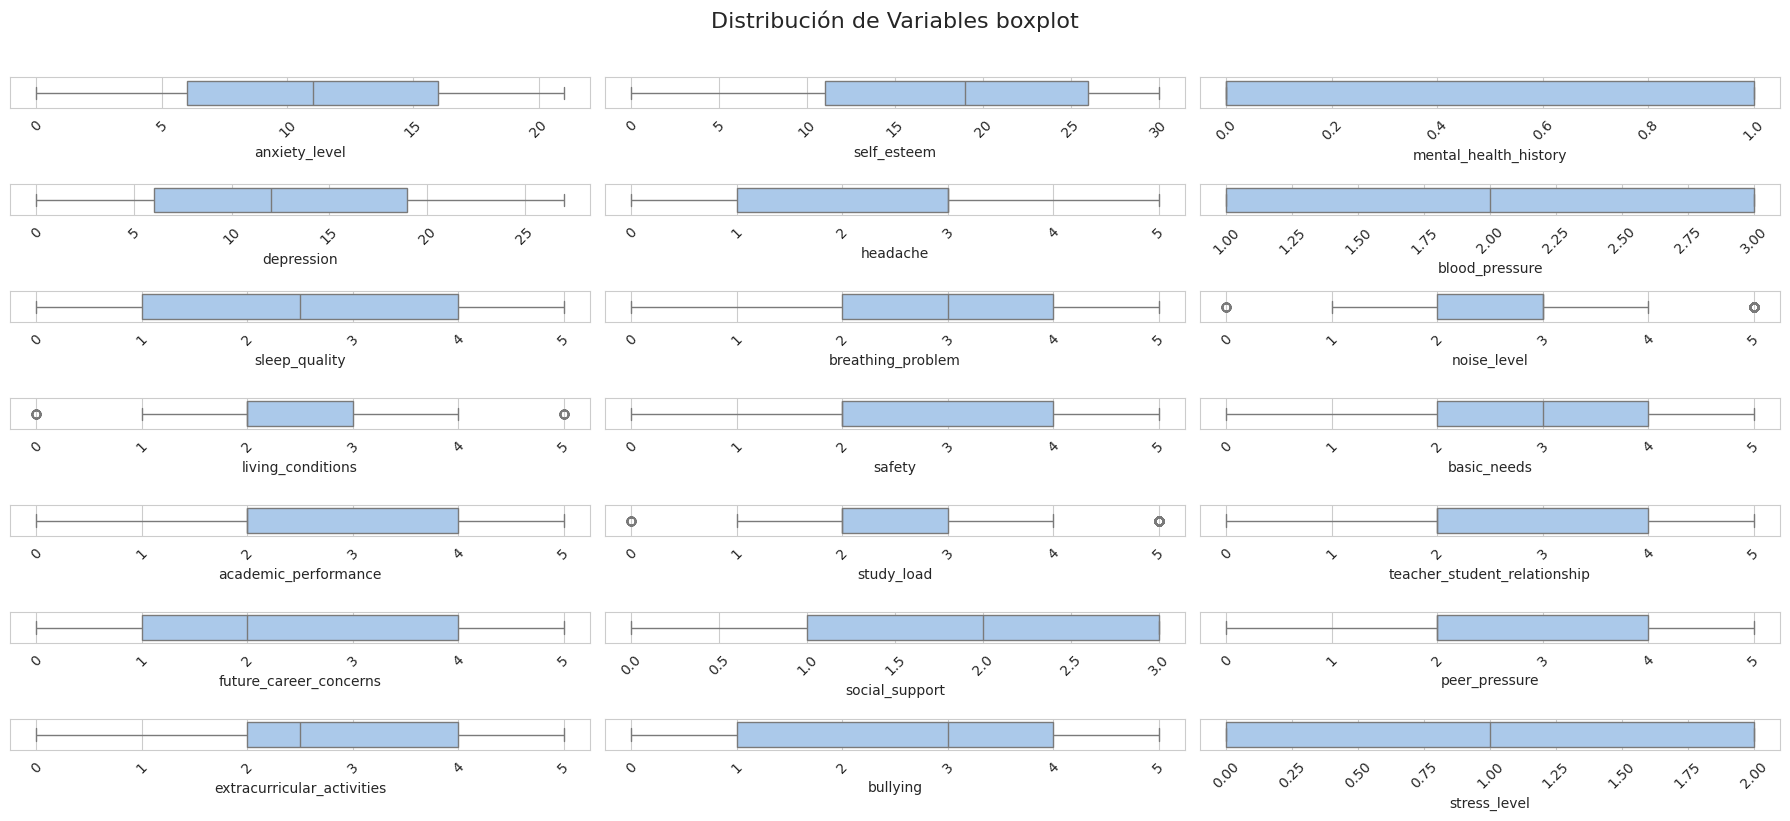

In [ ]:
#Visualizar variables en box-plt
# 1. Lista de columnas categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Configurar el layout de subgráficos (4 filas x 3 columnas)
fig, axes = plt.subplots(7, 3, figsize=(18, 8))  # Ajusta el tamaño según necesidad
fig.suptitle('Distribución de Variables boxplot', y=1.02, fontsize=16)

# 3. Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# 4. Generar los gráficos
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], palette='pastel')

    axes[i].tick_params(axis='x', rotation=45)  # Rotación para etiquetas largas

# 5. Eliminar ejes vacíos si hay menos de 15 gráficos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

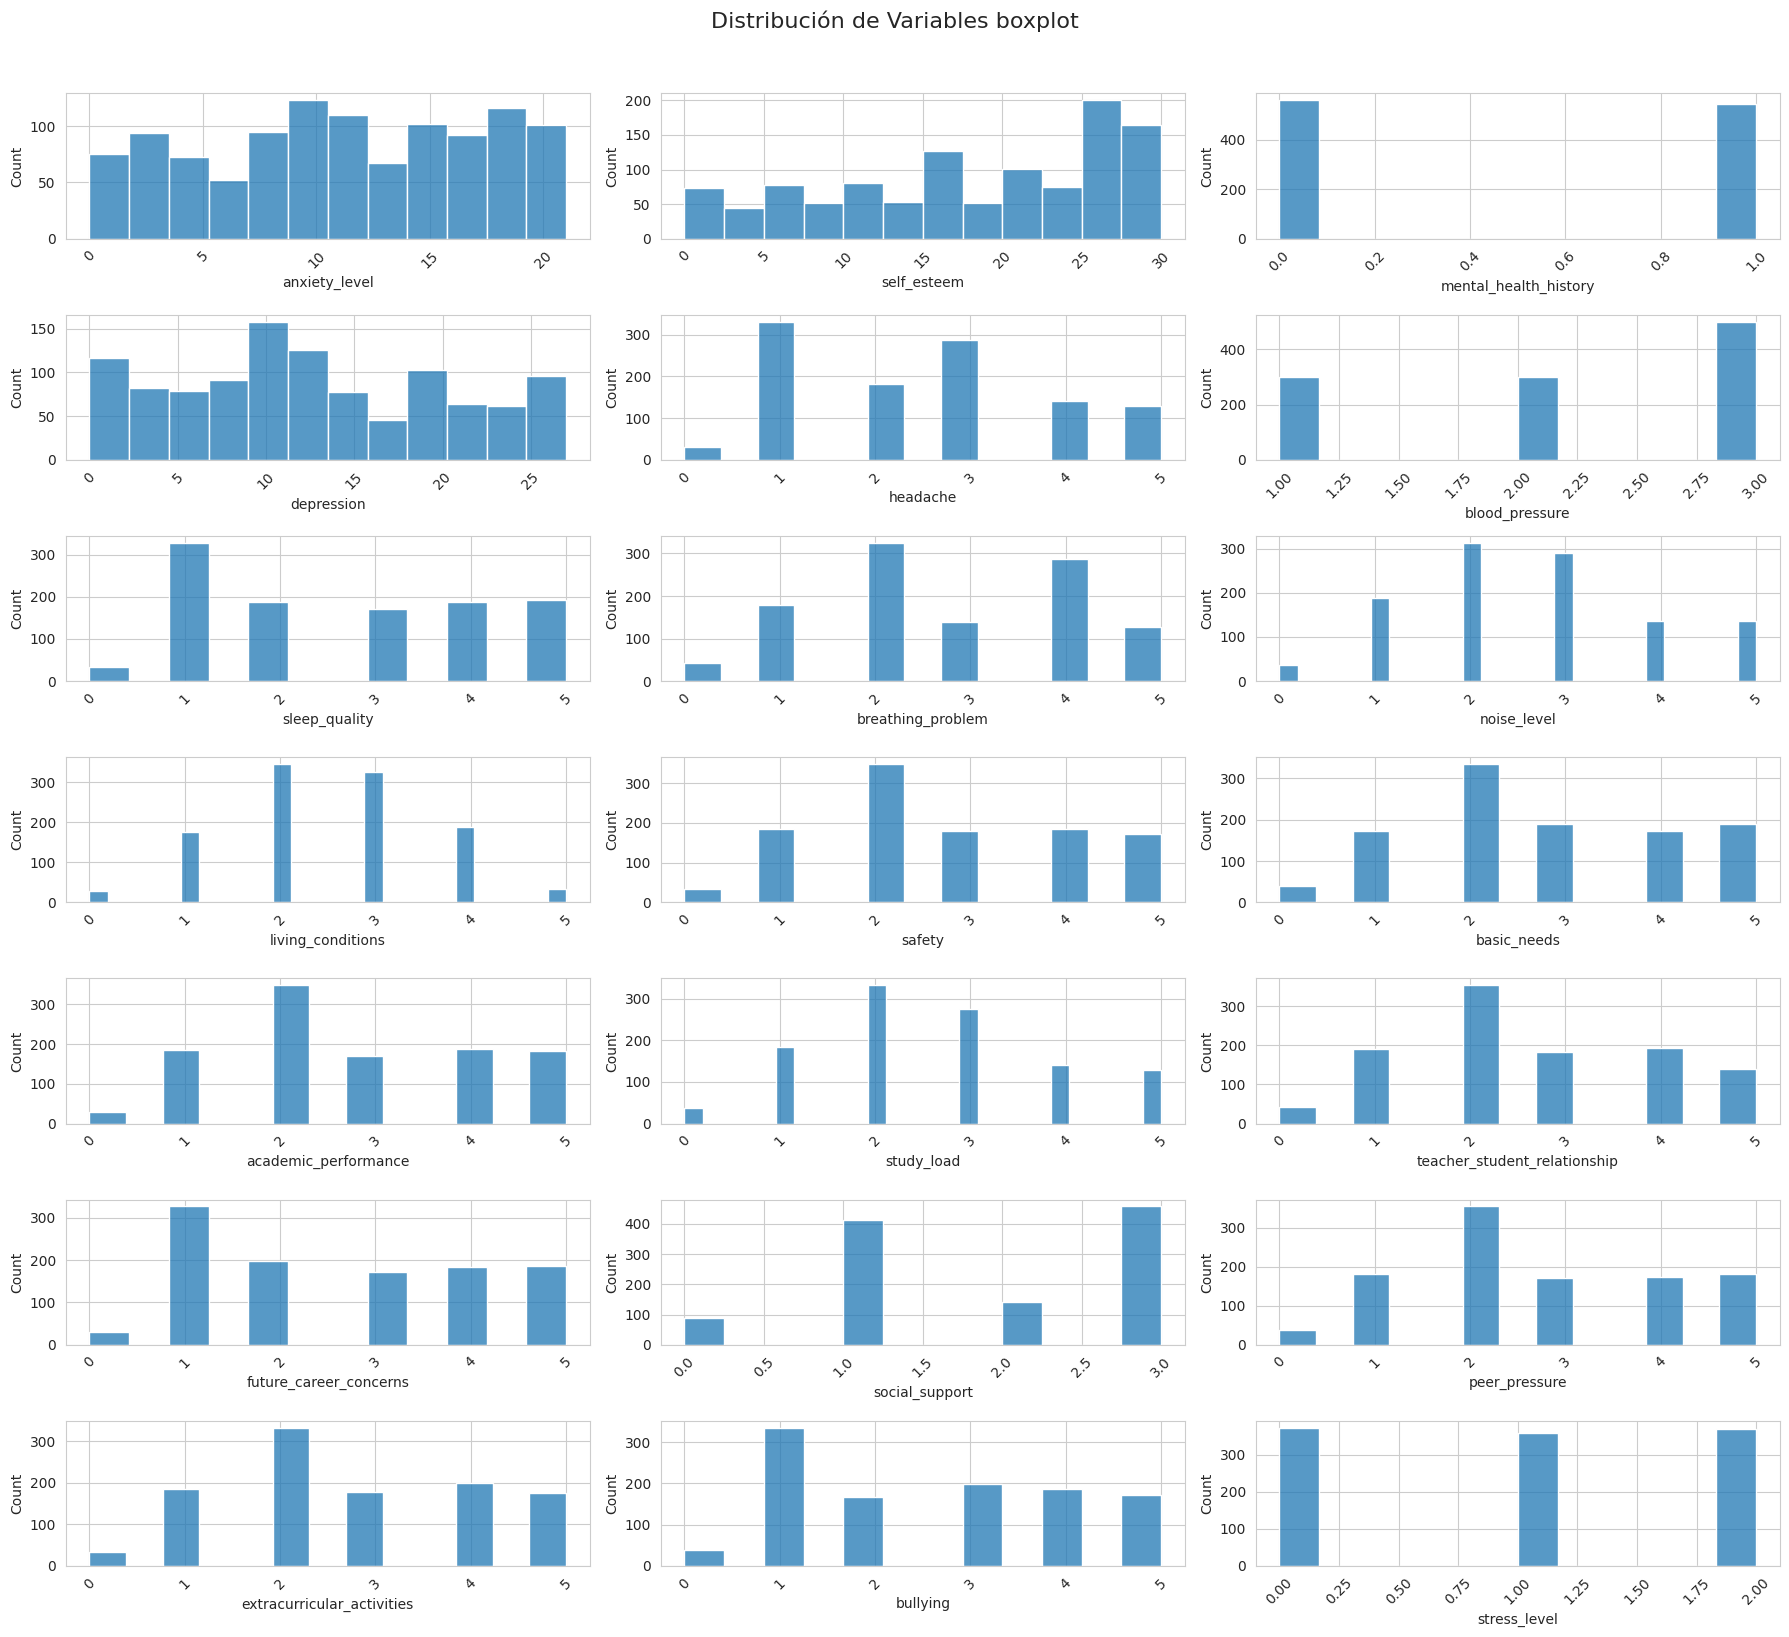

In [ ]:
#Visualizar variables en box-plt
# 1. Lista de columnas categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Configurar el layout de subgráficos (7 filas x 3 columnas)
fig, axes = plt.subplots(7, 3, figsize=(18, 16))  # Ajusta el tamaño según necesidad
fig.suptitle('Distribución de Variables boxplot', y=1.02, fontsize=16)

# 3. Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# 4. Generar los gráficos
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i], palette='pastel')

    axes[i].tick_params(axis='x', rotation=45)  # Rotación para etiquetas largas

# 5. Eliminar ejes vacíos si hay menos de 15 gráficos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se podria normalizar las variables  anxiety_level, self_esteem y depression para que no causen problemas en ciertos modelos de análisis (como Regresión Logística o KNN). En tanto las variables  categóricas ya están convertidas en números (como las escalas mencionadas, pero en fomrato int), por lo que podria trabajrse como estan o hacer  un cambio de int a cat (opcional, mejora el rendimiento en modelos como RF).  No existe presencia de atipicos. Se encuentra balanceado el target.

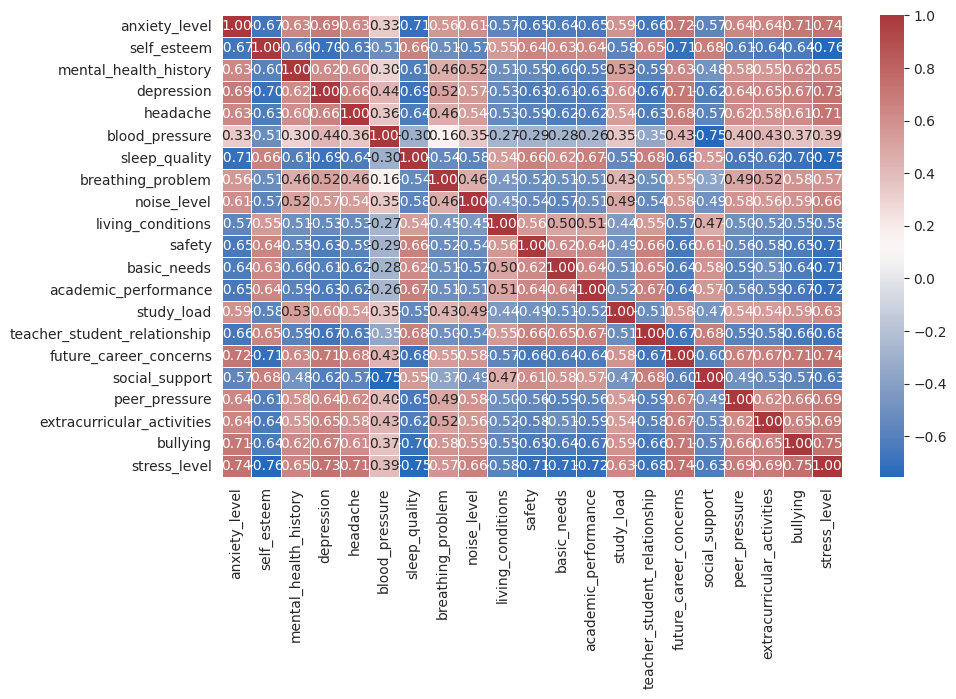

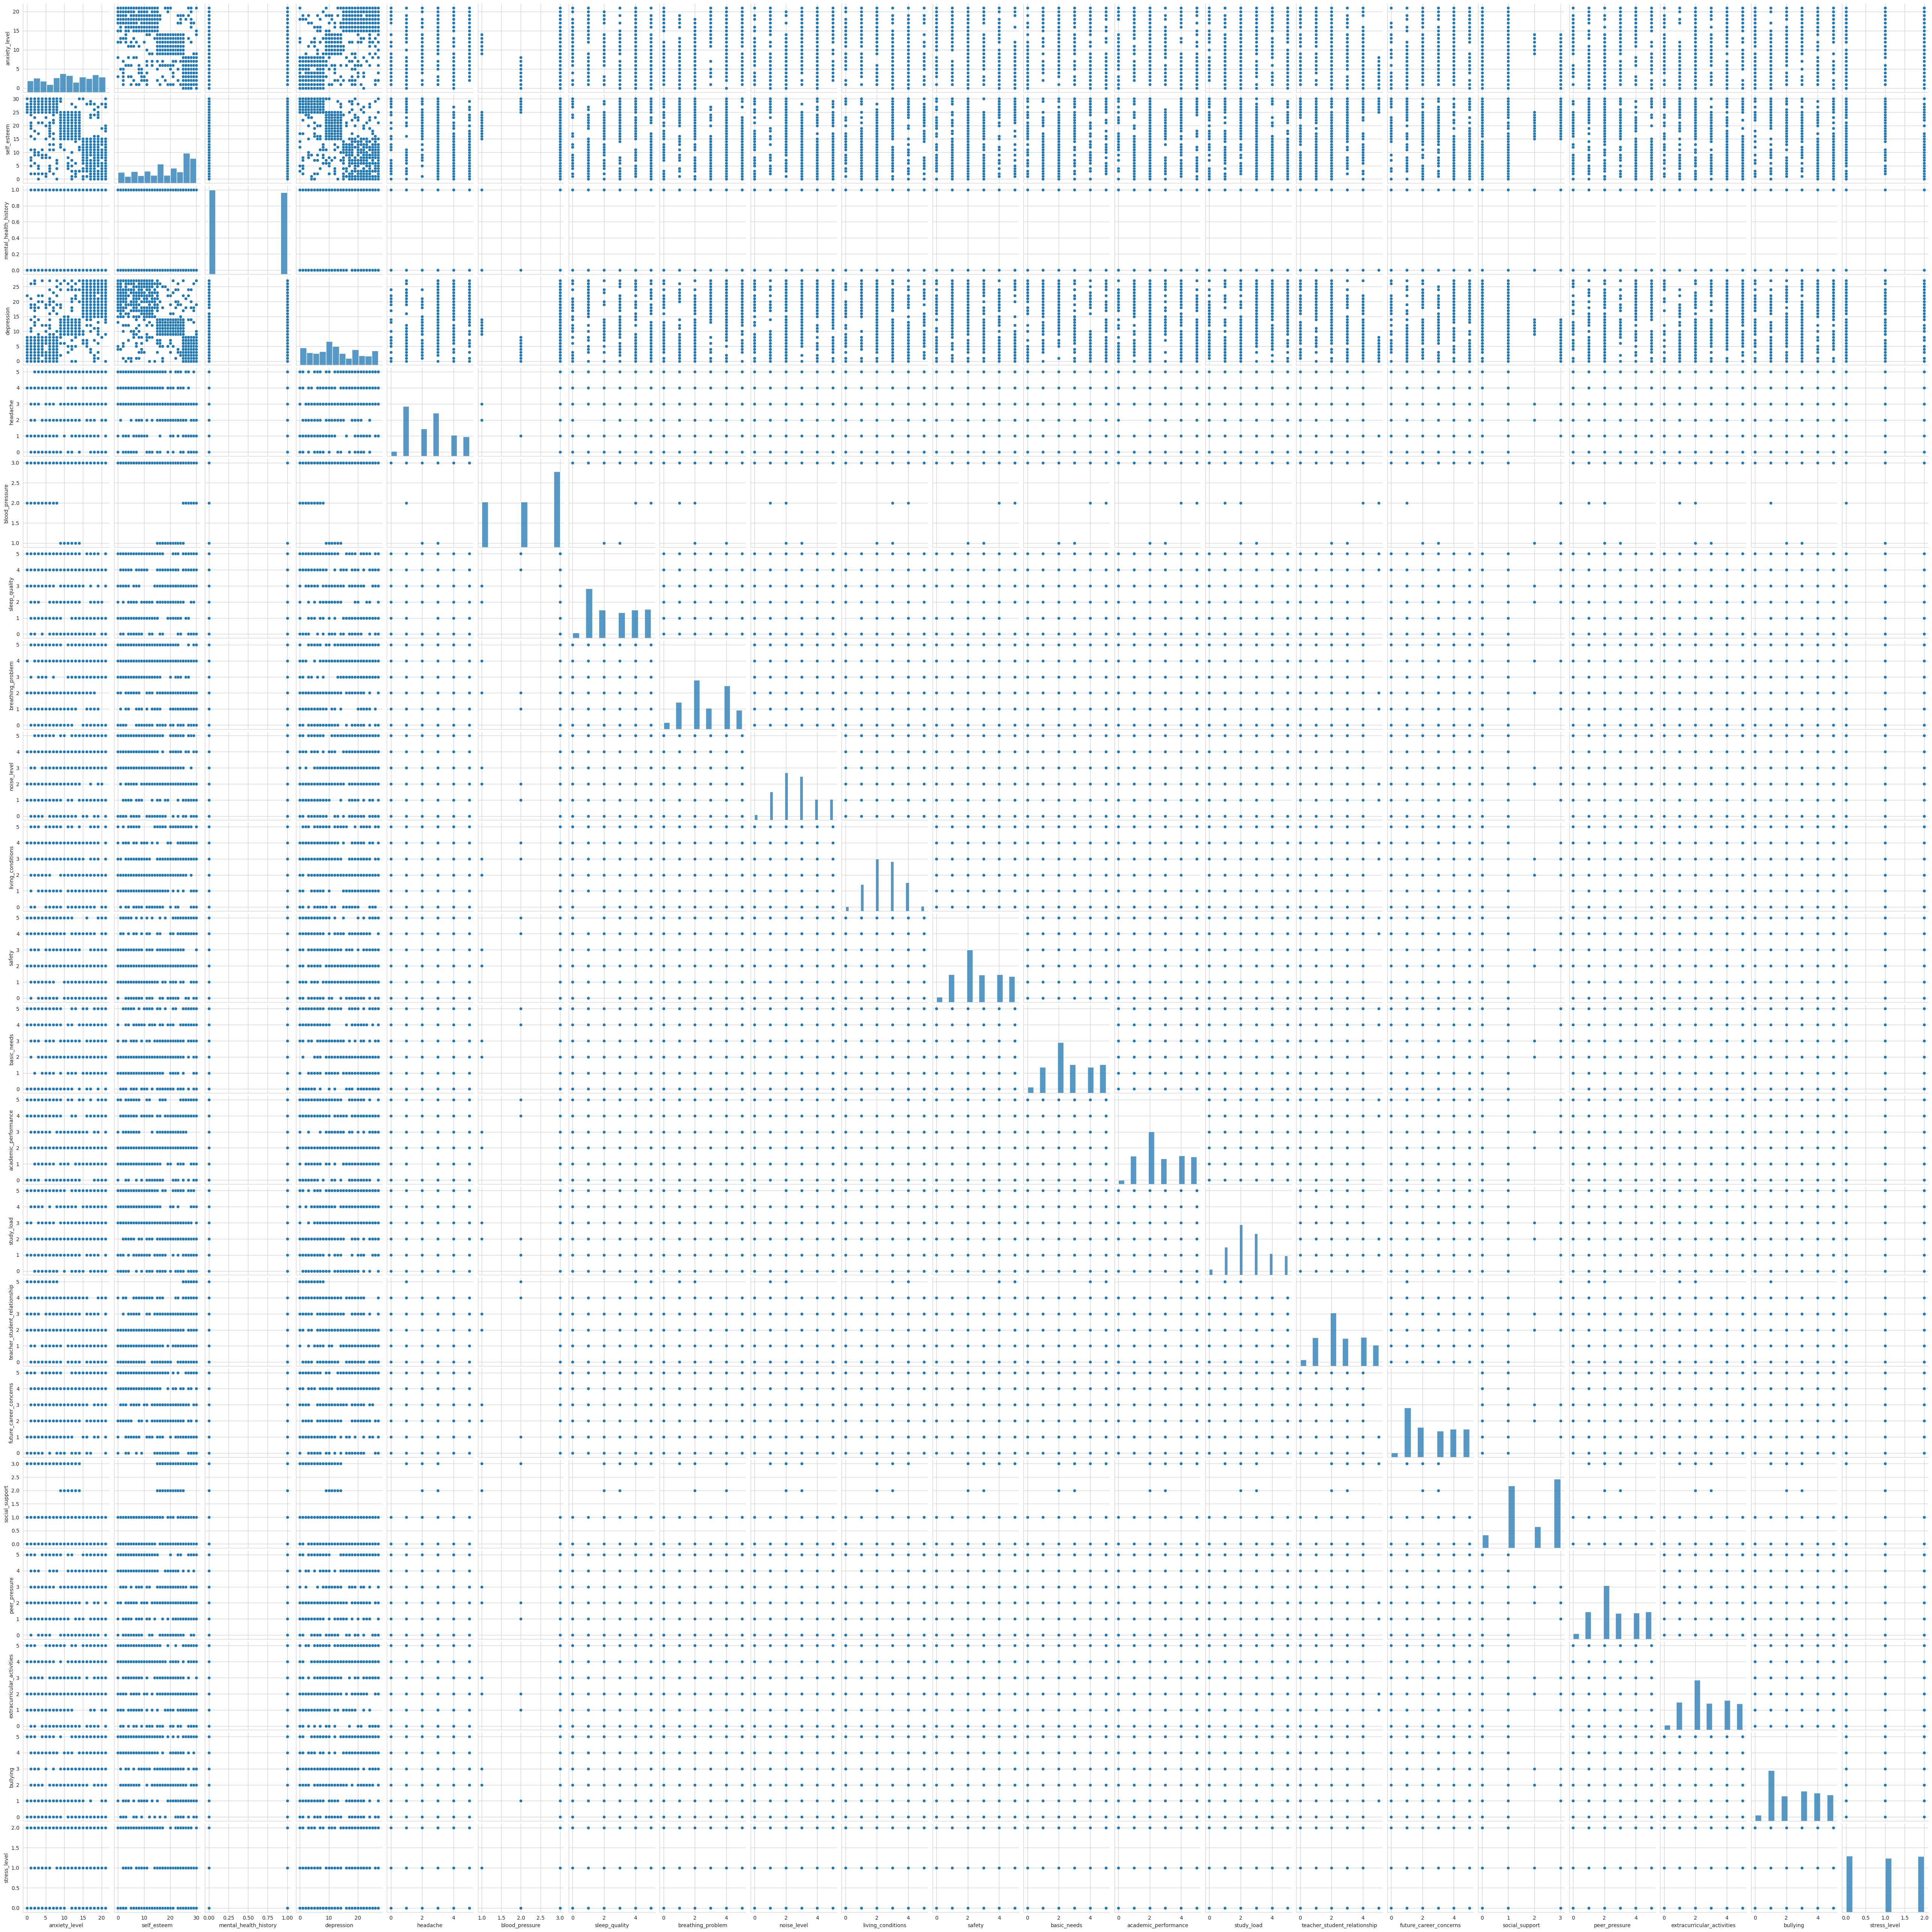

In [ ]:
#Visualizacion de las correlaciones entre las variables
# Matriz de correlación
correlation_matrix_df= df.corr()
#Visualizacion
sns.heatmap(correlation_matrix_df, annot=True, cmap="vlag", linewidths=0.5,fmt=".2f")
sns.pairplot(df)

La matriz de correlacion muestra deiferentes relaciones relevantes con las diferentes features del dataset respecto al target (stress_level). Visualizando el pairplot, se nota una nube de puntos (al ser escalas, es dificil distinguir una correlacion), con lo cual se toma de forma cautelosa los resultados de la matriz de correlacion.

Se transforma todas las variables en categoricas excepto anxiety_level, self_esteem y depression las cuales quedan como enteros para despues aplicar StandarScale

In [ ]:
#Genero una copia del dataset
df_train=df.copy()
df_train =df_train.astype('category')
df_train['anxiety_level'] = df_train['anxiety_level'].astype('int')
df_train['self_esteem'] = df_train['self_esteem'].astype('int')
df_train['depression'] = df_train['depression'].astype('int')
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   anxiety_level                 1100 non-null   int64   
 1   self_esteem                   1100 non-null   int64   
 2   mental_health_history         1100 non-null   category
 3   depression                    1100 non-null   int64   
 4   headache                      1100 non-null   category
 5   blood_pressure                1100 non-null   category
 6   sleep_quality                 1100 non-null   category
 7   breathing_problem             1100 non-null   category
 8   noise_level                   1100 non-null   category
 9   living_conditions             1100 non-null   category
 10  safety                        1100 non-null   category
 11  basic_needs                   1100 non-null   category
 12  academic_performance          1100 non-null   ca

Preparo los datos para el modelado posterior

In [ ]:
#Defino las columnas de features
numeric_cols = ['anxiety_level', 'self_esteem', 'depression']
categorical_cols = ['mental_health_history', 'headache', 'blood_pressure',
                   'sleep_quality', 'breathing_problem', 'noise_level',
                   'living_conditions', 'safety', 'basic_needs',
                   'academic_performance', 'study_load',
                   'teacher_student_relationship', 'future_career_concerns',
                   'social_support', 'peer_pressure', 'extracurricular_activities',
                   'bullying']

#Etiqueto el df en funcion de x e y
X = df_train.drop("stress_level", axis=1)
y = df_train["stress_level"]

#Divido el df para el entrenamiento 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#Se escala los valores numericos mediante StandarScale (se puede usar RoboustScaler si hat muchos atipicos)
scaler = StandardScaler()
X_train_numeric = scaler.fit_transform(X_train[numeric_cols]) # Ajustar y transformar training data
X_test_numeric = scaler.transform(X_test[numeric_cols]) # Transformar test data (SOLO transform, NO fit_transform)

#Obtener variables categóricas
X_train_categorical = X_train[categorical_cols].values
X_test_categorical = X_test[categorical_cols].values

#Combino numéricas escaladas + categóricas
X_train_processed = np.concatenate([X_train_numeric, X_train_categorical], axis=1)
X_test_processed = np.concatenate([X_test_numeric, X_test_categorical], axis=1)




# Modelo de Regresion Logistica

**Inicialmente se entrenara con un Holdout simple 70/30**

Modelo de Regresión Logística Entrenado

--- Regresión Logística Multiclase ---
Accuracy en el conjunto de validación: 0.8848
ROC AUC Score (ovr): 0.9851
Precision: 0.8860
Recall: 0.8848
F1-Score: 0.8851


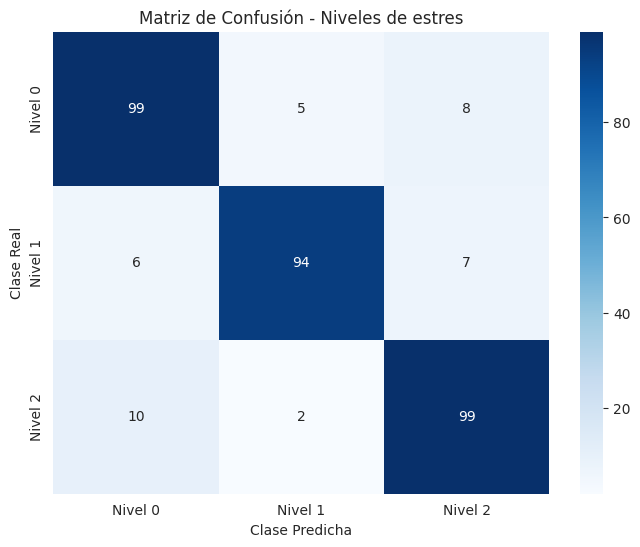

In [ ]:
#Modelo de regresion Logistica
model_reglog = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
model_reglog.fit(X_train_processed, y_train)
print("Modelo de Regresión Logística Entrenado")

#Realizar predicciones en el conjunto de validación
y_pred_reglog = model_reglog.predict(X_test_processed)
y_pred_proba_reglog = model_reglog.predict_proba(X_test_processed) # Todas las probabilidades

#Evaluo el modelo
print("\n--- Regresión Logística Multiclase ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_reglog):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_reglog, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_reglog, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_reglog, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_reglog, average='weighted'):.4f}")

#Visualizacion de matriz de confusion
cm = confusion_matrix(y_test, y_pred_reglog)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()

#Metricas en variables
accuracy_rl_h = round(accuracy_score(y_test, y_pred_reglog), 4)
auc_rl_ovr_h =  round(roc_auc_score(y_test, y_pred_proba_reglog, multi_class='ovr'),4)

**Ahora se probara el modelo mediante validacion cruzada con 5 folds**



In [ ]:
#Configurando K-Fold (5 folds estratificados)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Lista para almacenar resultados
results = []

print("Iniciando Validación Cruzada 5-Fold...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"--- Fold {fold}/5 ---")

    #Divido los  datos en entrenamiento y validacion
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    #Preprocesamiento de escalado (solo fit para train, para val solo tranformacion)
    scaler = StandardScaler()
    X_train_numeric = scaler.fit_transform(X_train_fold[numeric_cols])
    X_val_numeric = scaler.transform(X_val_fold[numeric_cols])

    #Combino numéricas escaladas + categóricas
    X_train_processed_vc = np.concatenate([
        X_train_numeric,
        X_train_fold[categorical_cols].values
    ], axis=1)

    X_val_processed_vc = np.concatenate([
        X_val_numeric,
        X_val_fold[categorical_cols].values
    ], axis=1)

    #Modelo
    model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
    model.fit(X_train_processed_vc, y_train_fold)

    #Prediccion
    y_pred = model.predict(X_val_processed_vc)
    y_pred_proba = model.predict_proba(X_val_processed_vc)

    #Metricas
    accuracy = accuracy_score(y_val_fold, y_pred)
    roc_auc_ovr = roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr')
    precision = precision_score(y_val_fold, y_pred, average='weighted')
    recall = recall_score(y_val_fold, y_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    #Alamacenamiento de resultados
    results.append({
        'fold': fold,
        'accuracy': accuracy,
        'roc_auc_ovr': roc_auc_ovr,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc_ovr:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

#Df de los resultados
results_df = pd.DataFrame(results)

print("=" * 50)
print("RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION")
print("=" * 50)

print("\n Métricas por fold:")
print(results_df)

print("\n Promedios y desviaciones estándar:")
print(f"Accuracy: {results_df['accuracy'].mean():.4f} (±{results_df['accuracy'].std():.4f})")
print(f"ROC AUC: {results_df['roc_auc_ovr'].mean():.4f} (±{results_df['roc_auc_ovr'].std():.4f})")
print(f"Precision: {results_df['precision'].mean():.4f} (±{results_df['precision'].std():.4f})")
print(f"Recall: {results_df['recall'].mean():.4f} (±{results_df['recall'].std():.4f})")
print(f"F1-Score: {results_df['f1'].mean():.4f} (±{results_df['f1'].std():.4f})")

#Preprocesamiento final con todso los datos
scaler_final = StandardScaler()
X_numeric_scaled = scaler_final.fit_transform(X[numeric_cols])

 #Combino numéricas escaladas + categóricas
X_final_processed = np.concatenate([
    X_numeric_scaled,
    X[categorical_cols].values
], axis=1)

#Metricas en variables
accuracy_rl_vc = round(results_df['accuracy'].mean(), 4)
auc_rl_ovr_vc =  round(results_df['roc_auc_ovr'].mean(),4)

Iniciando Validación Cruzada 5-Fold...

--- Fold 1/5 ---
Accuracy: 0.9227
ROC AUC: 0.9893
Precision: 0.9233
Recall: 0.9227
F1-Score: 0.9227

--- Fold 2/5 ---
Accuracy: 0.9045
ROC AUC: 0.9892
Precision: 0.9050
Recall: 0.9045
F1-Score: 0.9046

--- Fold 3/5 ---
Accuracy: 0.8682
ROC AUC: 0.9786
Precision: 0.8689
Recall: 0.8682
F1-Score: 0.8683

--- Fold 4/5 ---
Accuracy: 0.8682
ROC AUC: 0.9792
Precision: 0.8687
Recall: 0.8682
F1-Score: 0.8682

--- Fold 5/5 ---
Accuracy: 0.8909
ROC AUC: 0.9844
Precision: 0.8917
Recall: 0.8909
F1-Score: 0.8910

RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION

 Métricas por fold:
   fold  accuracy  roc_auc_ovr  precision    recall        f1
0     1  0.922727     0.989343   0.923330  0.922727  0.922658
1     2  0.904545     0.989226   0.904986  0.904545  0.904574
2     3  0.868182     0.978623   0.868880  0.868182  0.868344
3     4  0.868182     0.979220   0.868726  0.868182  0.868206
4     5  0.890909     0.984352   0.891677  0.890909  0.891039

 Promedios y de

**Hay una diferencia minima en el accuracy (0.88 vs 0.89) que beneficia al modelo de validacion cruzada**

*Visualizacion del peso de las variables*

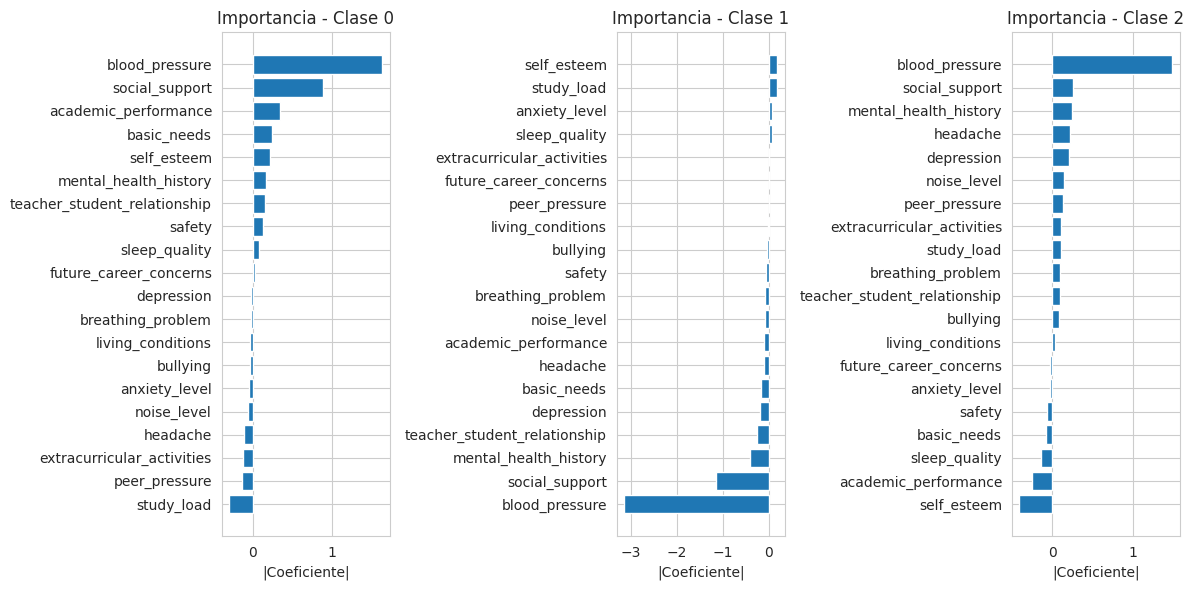

SHAP values calculados. Creando visualizaciones...

🔍 ANÁLISIS PARA CLASE 0:
Top 5 variables importantes para clase 0:
  - basic_needs
  - study_load
  - academic_performance
  - social_support
  - blood_pressure


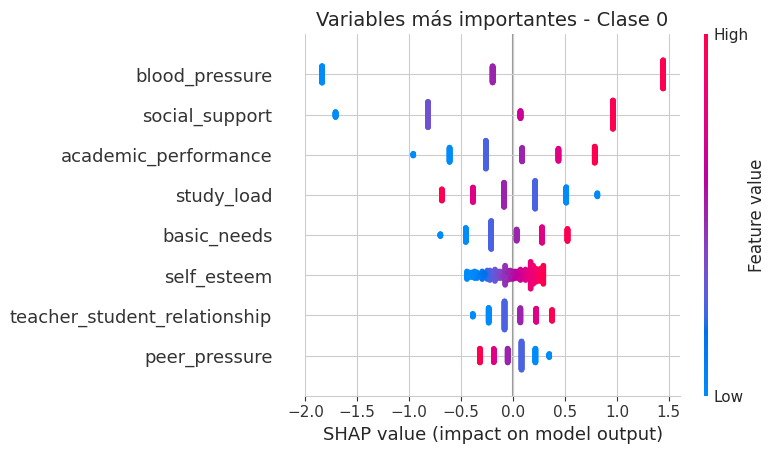


🔍 ANÁLISIS PARA CLASE 1:
Top 5 variables importantes para clase 1:
  - mental_health_history
  - study_load
  - teacher_student_relationship
  - social_support
  - blood_pressure


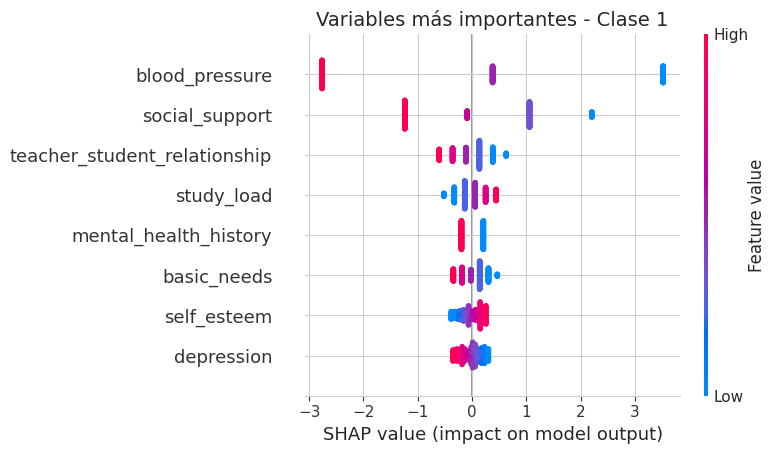


🔍 ANÁLISIS PARA CLASE 2:
Top 5 variables importantes para clase 2:
  - social_support
  - headache
  - academic_performance
  - self_esteem
  - blood_pressure


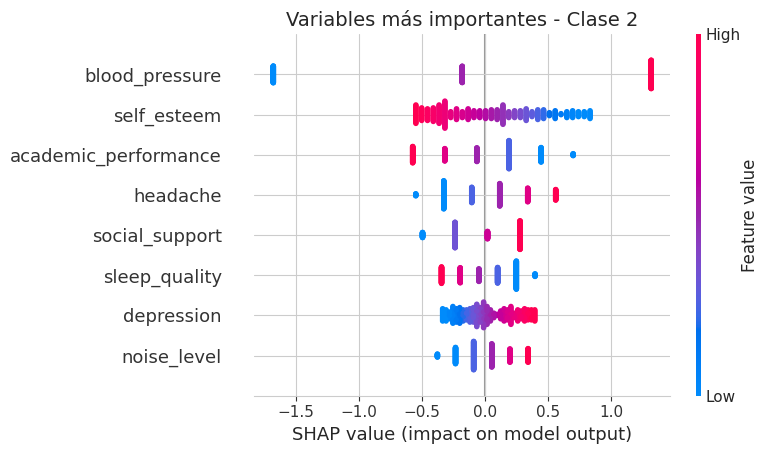

In [ ]:
#Creo matriz con nombres de las features
feature_names = numeric_cols + categorical_cols

# 1. Coeficientes del modelo
feature_names = numeric_cols + categorical_cols
coef_df = pd.DataFrame(model_reglog.coef_, columns=feature_names,
                      index=['Clase 0', 'Clase 1', 'Clase 2'])

# 2. Gráfico de coeficientes
plt.figure(figsize=(12, 6))
for i, clase in enumerate(coef_df.index):
    plt.subplot(1, 3, i+1)
    coef_vals = coef_df.loc[clase].sort_values(ascending=True)
    plt.barh(coef_vals.index, coef_vals.values)
    plt.title(f'Importancia - {clase}')
    plt.xlabel('|Coeficiente|')
plt.tight_layout()
plt.show()

# Configurar el estilo y tamaño de los gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
shap.initjs()  # Inicializar JS para visualizaciones

# 1. Crear el explainer de SHAP
explainer = shap.Explainer(model_reglog, X_train_processed, feature_names=numeric_cols + categorical_cols)

# 2. Calcular SHAP values para el conjunto de test
shap_values = explainer(X_test_processed)

# 3. Obtener los nombres de las features
feature_names = numeric_cols + categorical_cols

print("SHAP values calculados. Creando visualizaciones...")

# Análisis detallado por clase
for class_idx, class_name in enumerate(model_reglog.classes_):
    print(f"\n🔍 ANÁLISIS PARA CLASE {class_name}:")

    # SHAP values para esta clase
    shap_values_class = shap_values[:, :, class_idx]

    # Valores medios absolutos de SHAP (importancia)
    importance = np.mean(np.abs(shap_values_class.values), axis=0)
    top_features_idx = np.argsort(importance)[-5:]  # Top 5 features
    top_features = [feature_names[i] for i in top_features_idx]

    print(f"Top 5 variables importantes para clase {class_name}:")
    for feature in top_features:
        print(f"  - {feature}")

    # Gráfico individual por clase
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_class, X_test_processed,
                     feature_names=feature_names, plot_type="dot",
                     max_display=8, show=False)
    plt.title(f'Variables más importantes - Clase {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


# Modelo KNN

*Determino los vecinos mas cercanos optimos*

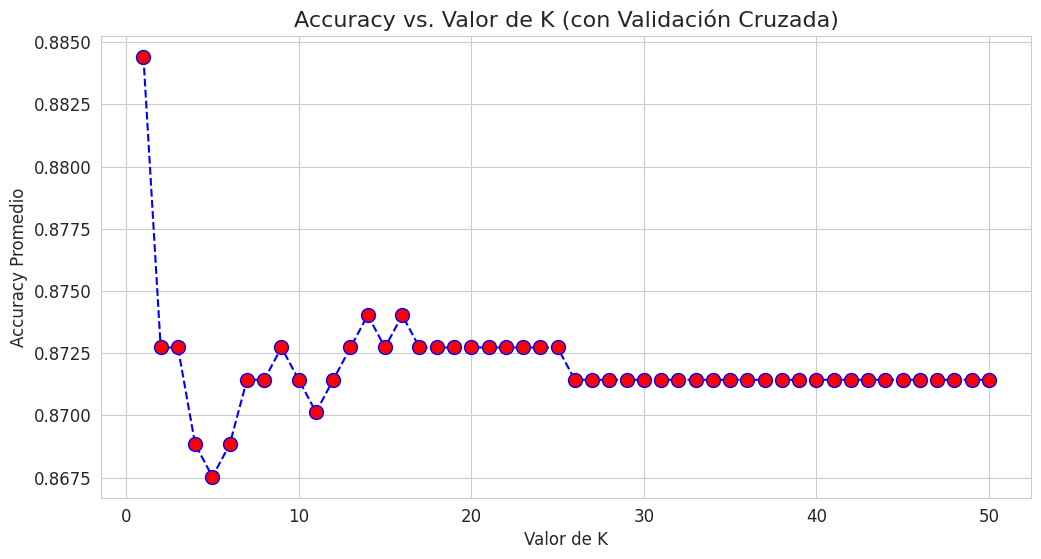

In [ ]:
#determino la cantidad de vecinos optima
from sklearn.model_selection import cross_val_score
# Rango de valores de k a probar (de 1 a 50)
k_range = range(1, 51)
k_scores = []

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Probar cada valor de k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Validación cruzada (5-fold) y cálculo del accuracy promedio
    score = cross_val_score(knn, X_train_processed , y_train, cv=cv, scoring='accuracy').mean()
    k_scores.append(score)

# Configurar y mostrar el gráfico
plt.figure(figsize=(12, 6))
plt.plot(k_range, k_scores, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Accuracy vs. Valor de K (con Validación Cruzada)', fontsize=16)
plt.xlabel('Valor de K', fontsize=12)
plt.ylabel('Accuracy Promedio', fontsize=12)
plt.grid(True)

plt.show()

se toma el hiperparametro k=14

**Inicialmente se entrenara con un Holdout simple 70/30**

Modelo de KNN Entrenado

--- KNN Multiclase ---
Accuracy en el conjunto de validación: 0.8576
ROC AUC Score (ovr): 0.9587
Precision: 0.8877
Recall: 0.8576
F1-Score: 0.8615


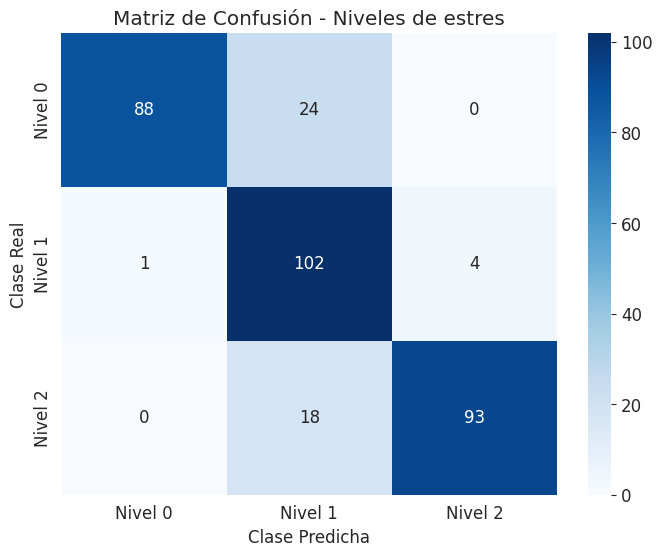

In [ ]:
#Ejecuto el modelo con k = 13 (valor optimizado del punto anterior)
model_knn = KNeighborsClassifier(n_neighbors=14)

# Entrenar el modelo
model_knn.fit(X_train_processed, y_train)
print("Modelo de KNN Entrenado")

#Realizar predicciones en el conjunto de validación
y_pred_knn = model_knn.predict(X_test_processed)
y_pred_proba_knn = model_knn.predict_proba(X_test_processed) # Todas las probabilidades

#Evaluo el modelo
print("\n--- KNN Multiclase ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_knn, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")


#Visualizacion de matriz de confusion
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()


#Metricas en variables
accuracy_knn_h = round(accuracy_score(y_test, y_pred_knn), 4)
auc_knn_ovr_h =  round(roc_auc_score(y_test, y_pred_proba_knn, multi_class='ovr'),4)


**Ahora se probara el modelo mediante validacion cruzada con 5 folds**

In [ ]:
#Configurando K-Fold (5 folds estratificados)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Lista para almacenar resultados
results = []

print("Iniciando Validación Cruzada 5-Fold...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"--- Fold {fold}/5 ---")

    #Divido los  datos en entrenamiento y validacion
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    #Preprocesamiento de escalado (solo fit para train, para val solo tranformacion)
    scaler = StandardScaler()
    X_train_numeric = scaler.fit_transform(X_train_fold[numeric_cols])
    X_val_numeric = scaler.transform(X_val_fold[numeric_cols])

    #Combino numéricas escaladas + categóricas
    X_train_processed_vc = np.concatenate([
        X_train_numeric,
        X_train_fold[categorical_cols].values
    ], axis=1)

    X_val_processed_vc = np.concatenate([
        X_val_numeric,
        X_val_fold[categorical_cols].values
    ], axis=1)

    #Modelo KNN
    model = KNeighborsClassifier(n_neighbors=14)
    model.fit(X_train_processed_vc, y_train_fold)

    #Prediccion
    y_pred = model.predict(X_val_processed_vc)
    y_pred_proba = model.predict_proba(X_val_processed_vc)

    #Metricas
    accuracy = accuracy_score(y_val_fold, y_pred)
    roc_auc_ovr = roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr')
    precision = precision_score(y_val_fold, y_pred, average='weighted')
    recall = recall_score(y_val_fold, y_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    #Alamacenamiento de resultados
    results.append({
        'fold': fold,
        'accuracy': accuracy,
        'roc_auc_ovr': roc_auc_ovr,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc_ovr:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

#Df de los resultados
results_df = pd.DataFrame(results)

print("=" * 50)
print("RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION")
print("=" * 50)

print("\n Métricas por fold:")
print(results_df)

print("\n Promedios y desviaciones estándar:")
print(f"Accuracy: {results_df['accuracy'].mean():.4f} (±{results_df['accuracy'].std():.4f})")
print(f"ROC AUC: {results_df['roc_auc_ovr'].mean():.4f} (±{results_df['roc_auc_ovr'].std():.4f})")
print(f"Precision: {results_df['precision'].mean():.4f} (±{results_df['precision'].std():.4f})")
print(f"Recall: {results_df['recall'].mean():.4f} (±{results_df['recall'].std():.4f})")
print(f"F1-Score: {results_df['f1'].mean():.4f} (±{results_df['f1'].std():.4f})")

#Metricas en variables
accuracy_knn_vc = round(results_df['accuracy'].mean(), 4)
auc_knn_ovr_vc =  round(results_df['roc_auc_ovr'].mean(),4)


Iniciando Validación Cruzada 5-Fold...

--- Fold 1/5 ---
Accuracy: 0.8636
ROC AUC: 0.9670
Precision: 0.8878
Recall: 0.8636
F1-Score: 0.8670

--- Fold 2/5 ---
Accuracy: 0.8909
ROC AUC: 0.9672
Precision: 0.9146
Recall: 0.8909
F1-Score: 0.8938

--- Fold 3/5 ---
Accuracy: 0.8500
ROC AUC: 0.9493
Precision: 0.8865
Recall: 0.8500
F1-Score: 0.8532

--- Fold 4/5 ---
Accuracy: 0.8636
ROC AUC: 0.9656
Precision: 0.8909
Recall: 0.8636
F1-Score: 0.8665

--- Fold 5/5 ---
Accuracy: 0.8773
ROC AUC: 0.9646
Precision: 0.9049
Recall: 0.8773
F1-Score: 0.8799

RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION

 Métricas por fold:
   fold  accuracy  roc_auc_ovr  precision    recall        f1
0     1  0.863636     0.966979   0.887777  0.863636  0.867015
1     2  0.890909     0.967245   0.914584  0.890909  0.893758
2     3  0.850000     0.949314   0.886471  0.850000  0.853208
3     4  0.863636     0.965611   0.890949  0.863636  0.866541
4     5  0.877273     0.964633   0.904879  0.877273  0.879916

 Promedios y de

Hay una diferencia minima en el accuracy (0.85 vs 0.86) y el ROC AUC (0.95 vs 0.96) que beneficia al modelo de validacion cruzada

*Visualizacion del peso de las variables (diferente a shap ya que el modelo juego mas con las distancias y shap no seria la mejor opcion para este caso)*

Modelo de KNN Entrenado
🔍 PERMUTATION IMPORTANCE - KNN
                       feature  importance_mean  importance_std
12        academic_performance         0.002424        0.003785
11                 basic_needs         0.002121        0.002727
18  extracurricular_activities         0.001818        0.002777
13                  study_load         0.001818        0.002424
1                  self_esteem         0.000909        0.003045
2                   depression         0.000606        0.003264
5               blood_pressure         0.000303        0.001632
10                      safety         0.000303        0.002859
4                     headache         0.000303        0.003442
16              social_support         0.000000        0.002347
9            living_conditions        -0.000909        0.001389
3        mental_health_history        -0.001212        0.001485
8                  noise_level        -0.001515        0.001515
0                anxiety_level        -0.002424  

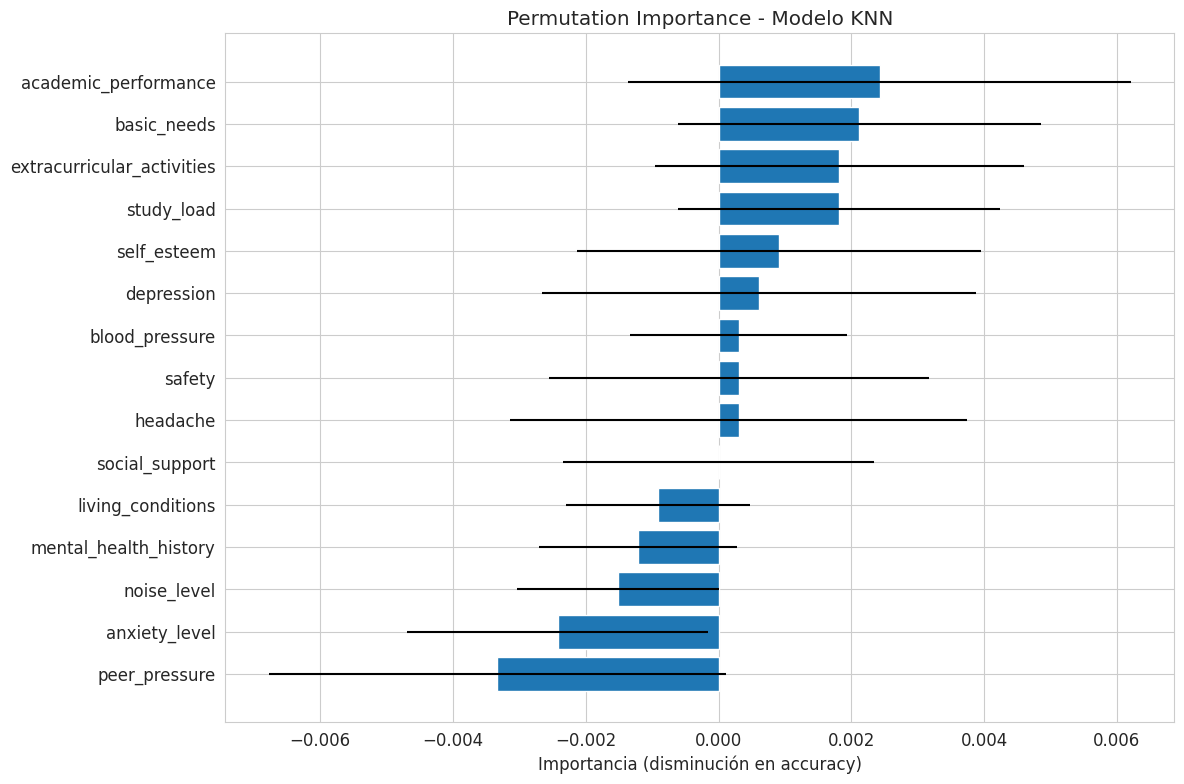

In [ ]:
#Ejecuto el modelo con k = 14 (valor optimizado del punto anterior)
model_knn = KNeighborsClassifier(n_neighbors=14)

# Entrenar el modelo
model_knn.fit(X_train_processed, y_train)
print("Modelo de KNN Entrenado")

# Calcular Permutation Importance
perm_importance = permutation_importance(
    model_knn,
    X_test_processed,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Crear DataFrame con resultados
feature_importance = pd.DataFrame({
    'feature': numeric_cols + categorical_cols,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("🔍 PERMUTATION IMPORTANCE - KNN")
print(feature_importance.head(15))

# Visualizar
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15],
         feature_importance['importance_mean'][:15],
         xerr=feature_importance['importance_std'][:15])
plt.xlabel('Importancia (disminución en accuracy)')
plt.title('Permutation Importance - Modelo KNN')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Modelo Random Forest

**Inicialmente se entrenara con un Holdout simple 70/30**


--- Random Forest ---
Accuracy en el conjunto de validación: 0.8727
ROC AUC Score (ovr): 0.9816
Precision: 0.8742
Recall: 0.8727
F1-Score: 0.8725


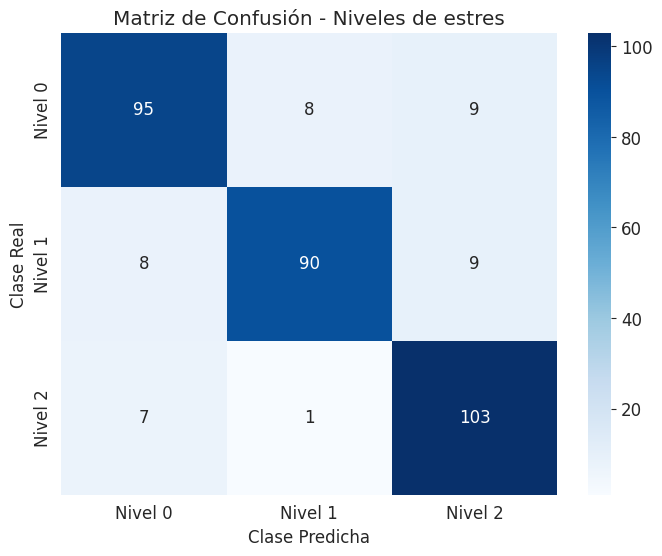

In [ ]:
#Genero el modelo de rf
rf_classifier = RandomForestClassifier(
    n_estimators=200,      # Número de árboles
    max_features=1.0,      # Uso todas las features
    max_depth=15,        # Profundidad máxima (None = hasta hojas puras)
    min_samples_split=5,   # Mínimo muestras para dividir nodo
    min_samples_leaf=2,    # Mínimo muestras en hoja
    class_weight='balanced',  # Balanceo de la muestra
    random_state=42        # Reproducibilidad
)
#Ejecuto el modelo
rf_classifier.fit(X_train_processed, y_train)

# Realizar predicciones
y_pred_model_rf = rf_classifier.predict(X_test_processed)
y_pred_proba_model_rf = rf_classifier.predict_proba(X_test_processed) # Todas las probabilidades

# Evaluar el modelo
print("\n--- Random Forest ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_model_rf):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_model_rf, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_model_rf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_model_rf, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_model_rf, average='weighted'):.4f}")

#Visualizacion de matriz de confusion
cm = confusion_matrix(y_test, y_pred_model_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()

*Optimizacion de los parametros apra aplicar random forest*

In [ ]:
# Optimizo parametros con GrindSearch
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],      # Más árboles = mejor performance, pero más lento
    'max_depth': [None, 10, 15, 20, 30, 40, 50],      # Controla complejidad (None = sin límite)
    'min_samples_split': [2, 5, 7, 10],      # Evita overfitting
    'min_samples_leaf': [1, 2, 4],        # Evita overfitting
    'max_features': ['auto', 'sqrt', 'log2']  # Número de features para split
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy', #se utiliza la metrica de accuracy para buscar los mejores parametros
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)
# Resultados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score de validación:", grid_search.best_score_)


Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Mejor score de validación: 0.887012987012987


*Repito el modelo de Rf con los parametros optimizados*


--- Random Forest ---
Accuracy en el conjunto de validación: 0.8727
ROC AUC Score (ovr): 0.9821
Precision: 0.8734
Recall: 0.8727
F1-Score: 0.8727


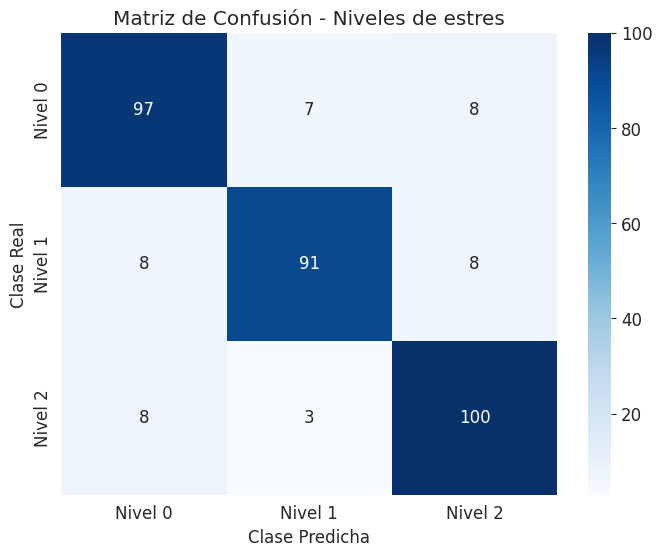

In [ ]:
#Genero el modelo de rf
rf_classifier = RandomForestClassifier(
    n_estimators=500,      # Número de árboles
    max_features='sqrt',   # Uso todas las features
    max_depth=None,        # Profundidad máxima (None = hasta hojas puras)
    min_samples_split=5,   # Mínimo muestras para dividir nodo
    min_samples_leaf=1,    # Mínimo muestras en hoja
    random_state=42        # Reproducibilidad
)
#Ejecuto el modelo
rf_classifier.fit(X_train_processed, y_train)

# Realizar predicciones
y_pred_model_rf = rf_classifier.predict(X_test_processed)
y_pred_proba_model_rf = rf_classifier.predict_proba(X_test_processed) # Todas las probabilidades

# Evaluar el modelo
print("\n--- Random Forest ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_model_rf):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_model_rf, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_model_rf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_model_rf, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_model_rf, average='weighted'):.4f}")

#Visualizacion de matriz de confusion
cm = confusion_matrix(y_test, y_pred_model_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()

#Metricas en variables
accuracy_rf_h = round(accuracy_score(y_test, y_pred_model_rf), 4)
auc_rf_ovr_h =  round(roc_auc_score(y_test, y_pred_proba_model_rf, multi_class='ovr'),4)

**Ahora se probara el modelo mediante validacion cruzada con 5 folds**

In [ ]:
#Configurando K-Fold (5 folds estratificados)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Lista para almacenar resultados
results = []

print("Iniciando Validación Cruzada 5-Fold...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"--- Fold {fold}/5 ---")

    #Divido los  datos en entrenamiento y validacion
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    #Preprocesamiento de escalado (solo fit para train, para val solo tranformacion)
    scaler = StandardScaler()
    X_train_numeric = scaler.fit_transform(X_train_fold[numeric_cols])
    X_val_numeric = scaler.transform(X_val_fold[numeric_cols])

    #Combino numéricas escaladas + categóricas
    X_train_processed_vc = np.concatenate([
        X_train_numeric,
        X_train_fold[categorical_cols].values
    ], axis=1)

    X_val_processed_vc = np.concatenate([
        X_val_numeric,
        X_val_fold[categorical_cols].values
    ], axis=1)

    #Modelo RF
    #Genero el modelo de rf
    model_rf = RandomForestClassifier(
        n_estimators=500,      # Número de árboles
        max_features='sqrt',   # Uso todas las features
        max_depth=None,        # Profundidad máxima (None = hasta hojas puras)
        min_samples_split=5,   # Mínimo muestras para dividir nodo
        min_samples_leaf=1,    # Mínimo muestras en hoja
        random_state=42        # Reproducibilidad
    )
    #Ejecuto el modelo
    model_rf.fit(X_train_processed_vc, y_train_fold)

    #Prediccion
    y_pred = model_rf.predict(X_val_processed_vc)
    y_pred_proba = model_rf.predict_proba(X_val_processed_vc)

    #Metricas
    accuracy = accuracy_score(y_val_fold, y_pred)
    roc_auc_ovr = roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr')
    precision = precision_score(y_val_fold, y_pred, average='weighted')
    recall = recall_score(y_val_fold, y_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    #Alamacenamiento de resultados
    results.append({
        'fold': fold,
        'accuracy': accuracy,
        'roc_auc_ovr': roc_auc_ovr,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc_ovr:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

#Df de los resultados
results_df = pd.DataFrame(results)

print("=" * 50)
print("RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION")
print("=" * 50)

print("\n Métricas por fold:")
print(results_df)

print("\n Promedios y desviaciones estándar:")
print(f"Accuracy: {results_df['accuracy'].mean():.4f} (±{results_df['accuracy'].std():.4f})")
print(f"ROC AUC: {results_df['roc_auc_ovr'].mean():.4f} (±{results_df['roc_auc_ovr'].std():.4f})")
print(f"Precision: {results_df['precision'].mean():.4f} (±{results_df['precision'].std():.4f})")
print(f"Recall: {results_df['recall'].mean():.4f} (±{results_df['recall'].std():.4f})")
print(f"F1-Score: {results_df['f1'].mean():.4f} (±{results_df['f1'].std():.4f})")

#Metricas en variables
accuracy_rf_vc = round(results_df['accuracy'].mean(), 4)
auc_rf_ovr_vc =  round(results_df['roc_auc_ovr'].mean(),4)

Iniciando Validación Cruzada 5-Fold...

--- Fold 1/5 ---
Accuracy: 0.8909
ROC AUC: 0.9877
Precision: 0.8994
Recall: 0.8909
F1-Score: 0.8913

--- Fold 2/5 ---
Accuracy: 0.8955
ROC AUC: 0.9855
Precision: 0.8972
Recall: 0.8955
F1-Score: 0.8955

--- Fold 3/5 ---
Accuracy: 0.8591
ROC AUC: 0.9779
Precision: 0.8612
Recall: 0.8591
F1-Score: 0.8593

--- Fold 4/5 ---
Accuracy: 0.8682
ROC AUC: 0.9839
Precision: 0.8691
Recall: 0.8682
F1-Score: 0.8679

--- Fold 5/5 ---
Accuracy: 0.8864
ROC AUC: 0.9837
Precision: 0.8874
Recall: 0.8864
F1-Score: 0.8865

RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION

 Métricas por fold:
   fold  accuracy  roc_auc_ovr  precision    recall        f1
0     1  0.890909     0.987703   0.899377  0.890909  0.891306
1     2  0.895455     0.985515   0.897209  0.895455  0.895513
2     3  0.859091     0.977908   0.861160  0.859091  0.859328
3     4  0.868182     0.983860   0.869128  0.868182  0.867914
4     5  0.886364     0.983734   0.887376  0.886364  0.886495

 Promedios y de

*La diferencia entre holdout y validacion cruzada para el accuracy y AUC ROC es 0.87 vs 0.88 y 0.98 en ambos casos respectivamente*

*Visualizacion del peso de las features en el modelo de RF*

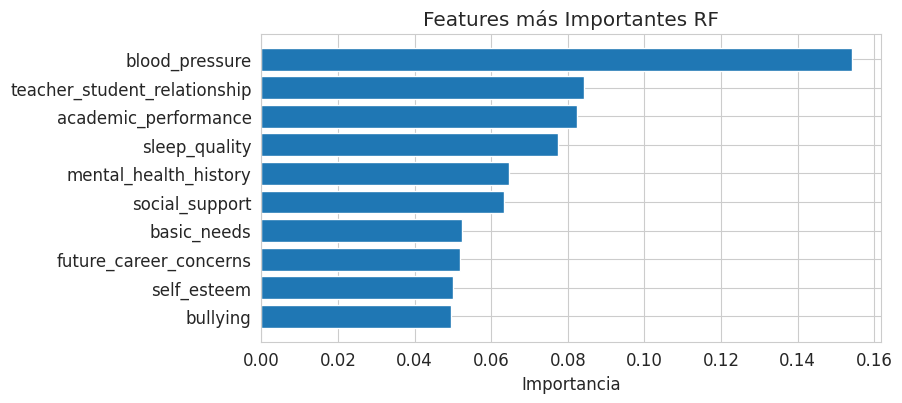

 99%|===================| 977/990 [00:42<00:00]       

SHAP values calculados. Creando visualizaciones...

🔍 ANÁLISIS PARA CLASE 0:
Top 5 variables importantes para clase 0:
  - headache
  - basic_needs
  - teacher_student_relationship
  - blood_pressure
  - academic_performance


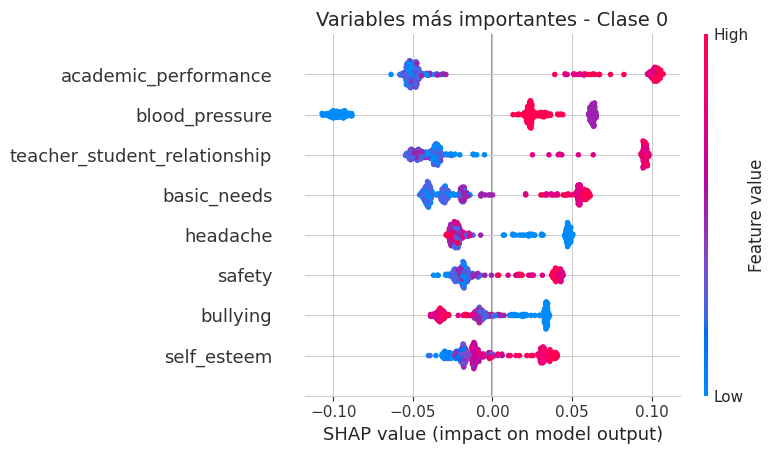


🔍 ANÁLISIS PARA CLASE 1:
Top 5 variables importantes para clase 1:
  - depression
  - social_support
  - academic_performance
  - teacher_student_relationship
  - blood_pressure


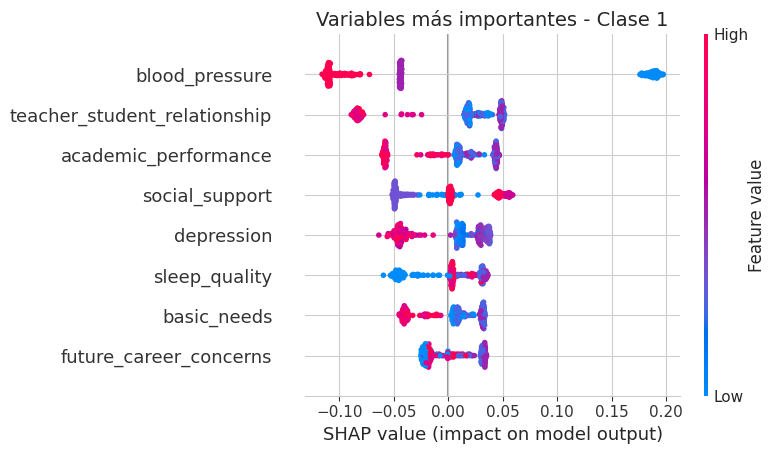


🔍 ANÁLISIS PARA CLASE 2:
Top 5 variables importantes para clase 2:
  - self_esteem
  - depression
  - social_support
  - sleep_quality
  - blood_pressure


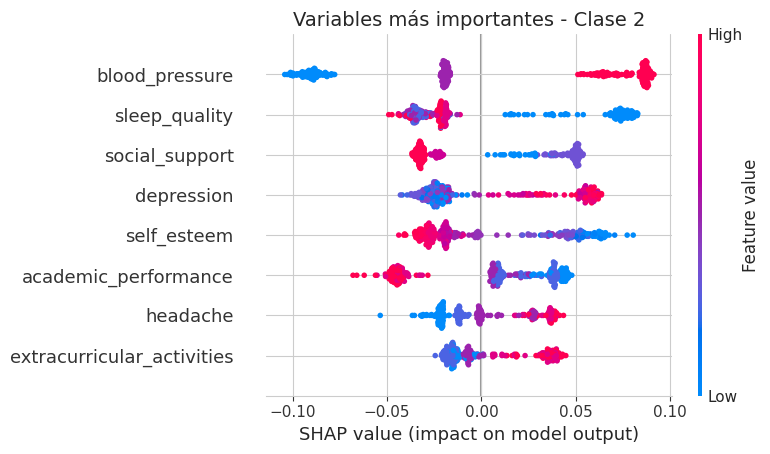

In [ ]:
# Importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)
# Visualizacion de la Importancia de features
plt.figure(figsize=(8, 4))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importancia')
plt.title('Features más Importantes RF')
plt.gca().invert_yaxis()
plt.show()

# Configurar el estilo y tamaño de los gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
shap.initjs()  # Inicializar JS para visualizaciones

#Visualizacion mediante Shap

# 1. Crear el explainer de SHAP
explainer = shap.Explainer(rf_classifier, X_train_processed, feature_names=numeric_cols + categorical_cols)

# 2. Calcular SHAP values para el conjunto de test
shap_values = explainer(X_test_processed)

# 3. Obtener los nombres de las features
feature_names = numeric_cols + categorical_cols

print("SHAP values calculados. Creando visualizaciones...")

# Análisis detallado por clase
for class_idx, class_name in enumerate(rf_classifier.classes_):
    print(f"\n🔍 ANÁLISIS PARA CLASE {class_name}:")

    # SHAP values para esta clase
    shap_values_class = shap_values[:, :, class_idx]

    # Valores medios absolutos de SHAP (importancia)
    importance = np.mean(np.abs(shap_values_class.values), axis=0)
    top_features_idx = np.argsort(importance)[-5:]  # Top 5 features
    top_features = [feature_names[i] for i in top_features_idx]

    print(f"Top 5 variables importantes para clase {class_name}:")
    for feature in top_features:
        print(f"  - {feature}")

    # Gráfico individual por clase
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_class, X_test_processed,
                     feature_names=feature_names, plot_type="dot",
                     max_display=8, show=False)
    plt.title(f'Variables más importantes - Clase {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


# Modelo XGBoost


--- Random Forest ---
Accuracy en el conjunto de validación: 0.8788
ROC AUC Score (ovr): 0.9832
Precision: 0.8798
Recall: 0.8788
F1-Score: 0.8789


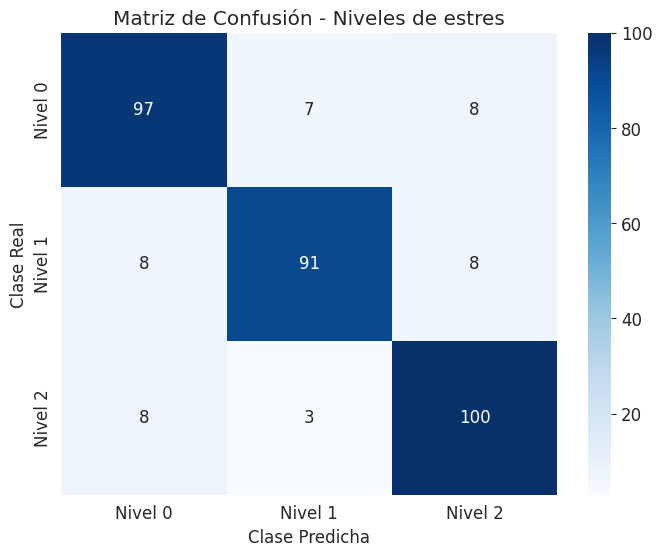

In [ ]:
#Genero el modelo y lo evaluo en funcion de los parametros
model_xgb =XGBClassifier(
            objective='multi:softprob',  # para multiple calsificacion
    num_class=3,                 # Para 3 clases
    n_estimators=100,           # Más árboles con learning rate bajo
    learning_rate=0.05,          # Learning rate bajo
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    #early_stopping_rounds=50,    # Parada temprana
    eval_metric='logloss'        # Métrica de evaluación
)
#Ejecuto el modelo
model_xgb.fit(X_train_processed, y_train)

# Realizar predicciones
y_pred_model_xgb = model_xgb.predict(X_test_processed)
y_pred_proba_model_xgb = model_xgb.predict_proba(X_test_processed) # Probabilidades para la clase positiva (1)


# Evaluar el modelo
print("\n--- Random Forest ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_model_xgb):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_model_xgb, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")

#Visualizacion de matriz de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()

#Metricas en variables
accuracy_xgb_h = round(accuracy_score(y_test, y_pred_model_xgb), 4)
auc_xgb_ovr_h =  round(roc_auc_score(y_test, y_pred_proba_model_xgb, multi_class='ovr'),4)


In [ ]:
#Parametro para optimizar el modelo
param_grid = {
    # Hiperparámetros principales
    'n_estimators': [100, 250, 500],          # Número de árboles
    'learning_rate': [0.01, 0.05, 0.1],       # Tasa de aprendizaje
    'max_depth': [3, 6, 10],                # Profundidad máxima

    # Regularización
    'reg_alpha': [0, 0.1, 0.5],               # Regularización L1
    'reg_lambda': [0.5, 1, 1.5],              # Regularización L2

    # Submuestreo
    'subsample': [0.8, 0.9, 1.0],             # Submuestra de instancias
    'colsample_bytree': [0.8, 0.9, 1.0],      # Submuestra de features por árbol

    # Para overfitting
    'min_child_weight': [1, 3, 5]             # Peso mínimo en hojas
}

# Modelo base para GridSearch
xgb_model = XGBClassifier(
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# Parametros
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',           # Métrica a optimizar
    cv=5,                         # 5-fold cross-validation
    n_jobs=-1,                    # Usar todos los núcleos
    verbose=2,                    # Mostrar progreso detallado
    refit=True,                   # Re-entrenar con mejores parámetros
    return_train_score=True       # Para análisis de overfitting
)

print("Iniciando GridSearch...")
grid_search.fit(X_train_processed, y_train)

print("¡Búsqueda completada!")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score de validación: {grid_search.best_score_:.4f}")

Iniciando GridSearch...
Fitting 5 folds for each of 6561 candidates, totalling 32805 fits
¡Búsqueda completada!
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 1.0}
Mejor score de validación: 0.9026


valores optimizadoss
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.01,
'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 1.0}
Mejor score de validación: 0.9026


*Modelo optimizado*


--- Random Forest ---
Accuracy en el conjunto de validación: 0.8758
ROC AUC Score (ovr): 0.9810
Precision: 0.8760
Recall: 0.8758
F1-Score: 0.8757


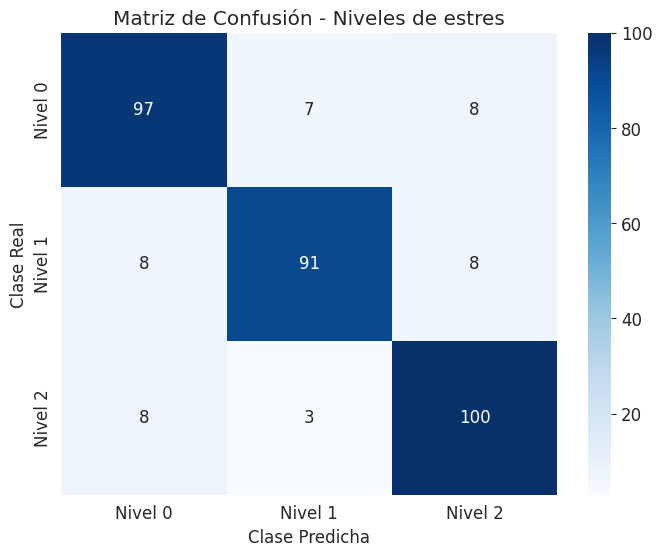

In [ ]:
#Genero el modelo y lo evaluo en funcion de los parametros
model_xgb =XGBClassifier(
            objective='multi:softprob',  # para multiple calsificacion
    num_class=3,                 # Para 3 clases
    n_estimators=100,           # Más árboles con learning rate bajo
    learning_rate=0.01,          # Learning rate bajo
    max_depth=3,
    subsample=1,
    colsample_bytree=1,
    min_child_weight= 5,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    #early_stopping_rounds=50,    # Parada temprana
    eval_metric='logloss'        # Métrica de evaluación
)
#Ejecuto el modelo
model_xgb.fit(X_train_processed, y_train)

# Realizar predicciones
y_pred_model_xgb = model_xgb.predict(X_test_processed)
y_pred_proba_model_xgb = model_xgb.predict_proba(X_test_processed) # Probabilidades para la clase positiva (1)


# Evaluar el modelo
print("\n--- Random Forest ---")
print(f"Accuracy en el conjunto de validación: {accuracy_score(y_test, y_pred_model_xgb):.4f}")
print(f"ROC AUC Score (ovr): {roc_auc_score(y_test, y_pred_proba_model_xgb, multi_class='ovr'):.4f}") #Evaluacion ROC AUC 1 vs Rest
print(f"Precision: {precision_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_model_xgb, average='weighted'):.4f}")

#Visualizacion de matriz de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'],
            yticklabels=['Nivel 0', 'Nivel 1', 'Nivel 2'])
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.title('Matriz de Confusión - Niveles de estres')
plt.show()

#Metricas en variables
accuracy_xgb_h = round(accuracy_score(y_test, y_pred_model_xgb), 4)
auc_xgb_ovr_h =  round(roc_auc_score(y_test, y_pred_proba_model_xgb, multi_class='ovr'),4)


**Ahora se probara el modelo mediante validacion cruzada con 5 folds**

In [ ]:
#Configurando K-Fold (5 folds estratificados)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Lista para almacenar resultados
results = []

print("Iniciando Validación Cruzada 5-Fold...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"--- Fold {fold}/5 ---")

    #Divido los  datos en entrenamiento y validacion
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    #Preprocesamiento de escalado (solo fit para train, para val solo tranformacion)
    scaler = StandardScaler()
    X_train_numeric = scaler.fit_transform(X_train_fold[numeric_cols])
    X_val_numeric = scaler.transform(X_val_fold[numeric_cols])

    #Combino numéricas escaladas + categóricas
    X_train_processed_vc = np.concatenate([
        X_train_numeric,
        X_train_fold[categorical_cols].values
    ], axis=1)

    X_val_processed_vc = np.concatenate([
        X_val_numeric,
        X_val_fold[categorical_cols].values
    ], axis=1)

    #Modelo RF
    #Genero el modelo de xgb
    model_xgb2 = RandomForestClassifier(
        n_estimators=500,      # Número de árboles
        max_features='sqrt',   # Uso todas las features
        max_depth=None,        # Profundidad máxima (None = hasta hojas puras)
        min_samples_split=5,   # Mínimo muestras para dividir nodo
        min_samples_leaf=1,    # Mínimo muestras en hoja
        random_state=42        # Reproducibilidad
    )
    #Ejecuto el modelo
    model_xgb2.fit(X_train_processed_vc, y_train_fold)

    #Prediccion
    y_pred = model_xgb2.predict(X_val_processed_vc)
    y_pred_proba = model_xgb2.predict_proba(X_val_processed_vc)

    #Metricas
    accuracy = accuracy_score(y_val_fold, y_pred)
    roc_auc_ovr = roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr')
    precision = precision_score(y_val_fold, y_pred, average='weighted')
    recall = recall_score(y_val_fold, y_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    #Alamacenamiento de resultados
    results.append({
        'fold': fold,
        'accuracy': accuracy,
        'roc_auc_ovr': roc_auc_ovr,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc_ovr:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

#Df de los resultados
results_df = pd.DataFrame(results)

print("=" * 50)
print("RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION")
print("=" * 50)

print("\n Métricas por fold:")
print(results_df)

print("\n Promedios y desviaciones estándar:")
print(f"Accuracy: {results_df['accuracy'].mean():.4f} (±{results_df['accuracy'].std():.4f})")
print(f"ROC AUC: {results_df['roc_auc_ovr'].mean():.4f} (±{results_df['roc_auc_ovr'].std():.4f})")
print(f"Precision: {results_df['precision'].mean():.4f} (±{results_df['precision'].std():.4f})")
print(f"Recall: {results_df['recall'].mean():.4f} (±{results_df['recall'].std():.4f})")
print(f"F1-Score: {results_df['f1'].mean():.4f} (±{results_df['f1'].std():.4f})")

#Metricas en variables
accuracy_xgb_vc = round(results_df['accuracy'].mean(), 4)
auc_xgb_ovr_vc =  round(results_df['roc_auc_ovr'].mean(),4)

Iniciando Validación Cruzada 5-Fold...

--- Fold 1/5 ---
Accuracy: 0.8909
ROC AUC: 0.9877
Precision: 0.8994
Recall: 0.8909
F1-Score: 0.8913

--- Fold 2/5 ---
Accuracy: 0.8955
ROC AUC: 0.9855
Precision: 0.8972
Recall: 0.8955
F1-Score: 0.8955

--- Fold 3/5 ---
Accuracy: 0.8591
ROC AUC: 0.9779
Precision: 0.8612
Recall: 0.8591
F1-Score: 0.8593

--- Fold 4/5 ---
Accuracy: 0.8682
ROC AUC: 0.9839
Precision: 0.8691
Recall: 0.8682
F1-Score: 0.8679

--- Fold 5/5 ---
Accuracy: 0.8864
ROC AUC: 0.9837
Precision: 0.8874
Recall: 0.8864
F1-Score: 0.8865

RESULTADOS FINALES DE 5-FOLD CROSS VALIDATION

 Métricas por fold:
   fold  accuracy  roc_auc_ovr  precision    recall        f1
0     1  0.890909     0.987703   0.899377  0.890909  0.891306
1     2  0.895455     0.985515   0.897209  0.895455  0.895513
2     3  0.859091     0.977908   0.861160  0.859091  0.859328
3     4  0.868182     0.983860   0.869128  0.868182  0.867914
4     5  0.886364     0.983734   0.887376  0.886364  0.886495

 Promedios y de

**No hay una diferencia notoria entre Holdout y validacion cruzada**

*Visualizacion del peso de las features en el modelo de XGBoost*

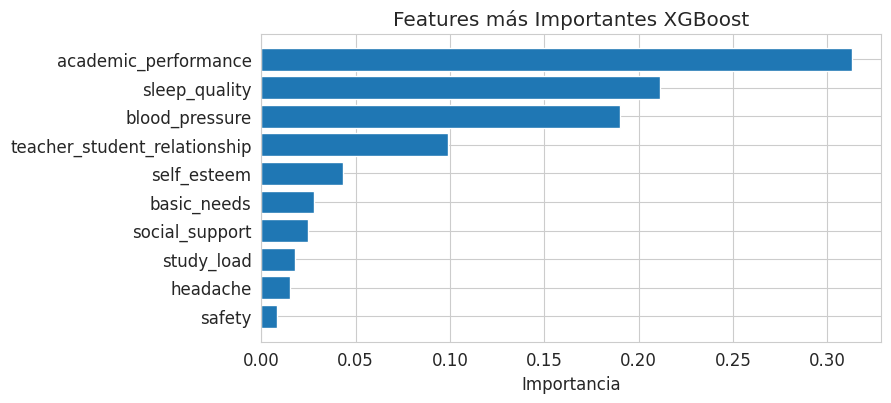

SHAP values calculados. Creando visualizaciones...

🔍 ANÁLISIS PARA CLASE 0:
Top 5 variables importantes para clase 0:
  - peer_pressure
  - self_esteem
  - study_load
  - teacher_student_relationship
  - academic_performance


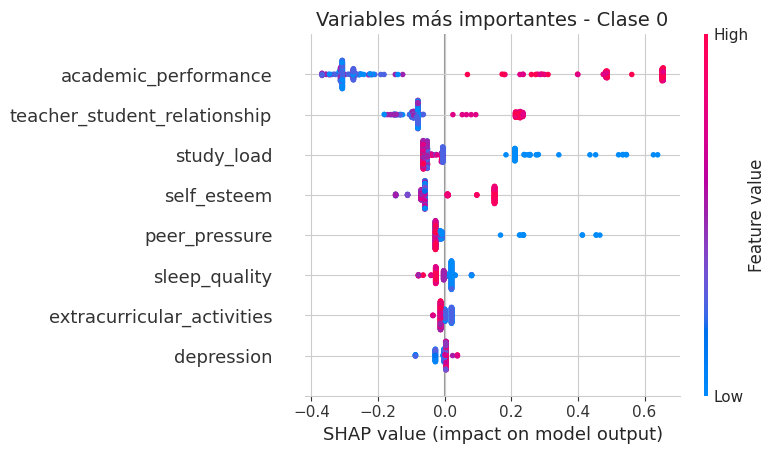


🔍 ANÁLISIS PARA CLASE 1:
Top 5 variables importantes para clase 1:
  - headache
  - mental_health_history
  - extracurricular_activities
  - social_support
  - blood_pressure


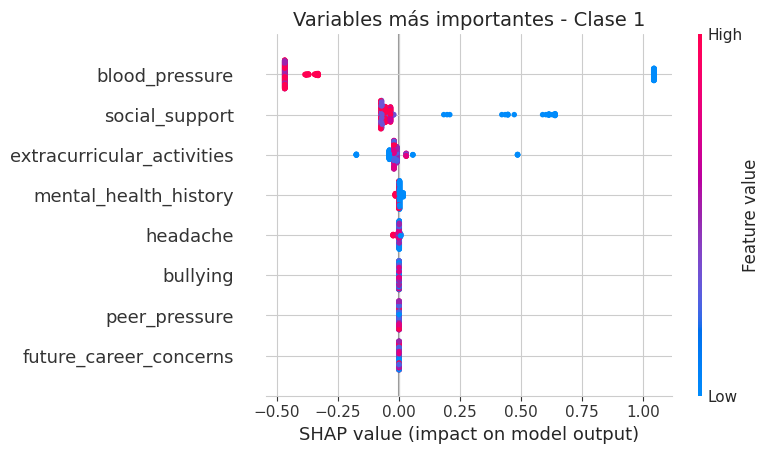


🔍 ANÁLISIS PARA CLASE 2:
Top 5 variables importantes para clase 2:
  - self_esteem
  - basic_needs
  - future_career_concerns
  - blood_pressure
  - sleep_quality


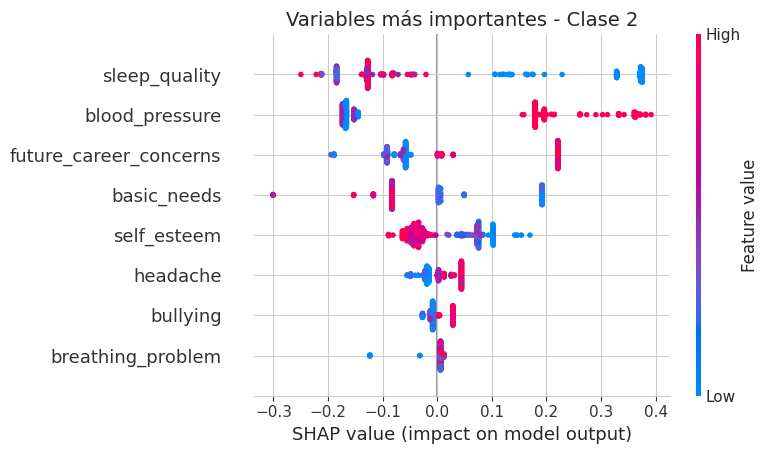

In [ ]:
# Importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)
# Visualizacion de la Importancia de features
plt.figure(figsize=(8, 4))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importancia')
plt.title('Features más Importantes XGBoost')
plt.gca().invert_yaxis()
plt.show()

# Configurar el estilo y tamaño de los gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
shap.initjs()  # Inicializar JS para visualizaciones

#Visualizacion mediante Shap

# 1. Crear el explainer de SHAP
explainer = shap.Explainer(model_xgb, X_train_processed, feature_names=numeric_cols + categorical_cols)

# 2. Calcular SHAP values para el conjunto de test
shap_values = explainer(X_test_processed)

# 3. Obtener los nombres de las features
feature_names = numeric_cols + categorical_cols

print("SHAP values calculados. Creando visualizaciones...")

# Análisis detallado por clase
for class_idx, class_name in enumerate(model_xgb.classes_):
    print(f"\n🔍 ANÁLISIS PARA CLASE {class_name}:")

    # SHAP values para esta clase
    shap_values_class = shap_values[:, :, class_idx]

    # Valores medios absolutos de SHAP (importancia)
    importance = np.mean(np.abs(shap_values_class.values), axis=0)
    top_features_idx = np.argsort(importance)[-5:]  # Top 5 features
    top_features = [feature_names[i] for i in top_features_idx]

    print(f"Top 5 variables importantes para clase {class_name}:")
    for feature in top_features:
        print(f"  - {feature}")

    # Gráfico individual por clase
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_class, X_test_processed,
                     feature_names=feature_names, plot_type="dot",
                     max_display=8, show=False)
    plt.title(f'Variables más importantes - Clase {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# **Resumen final con las metricas de analisis**

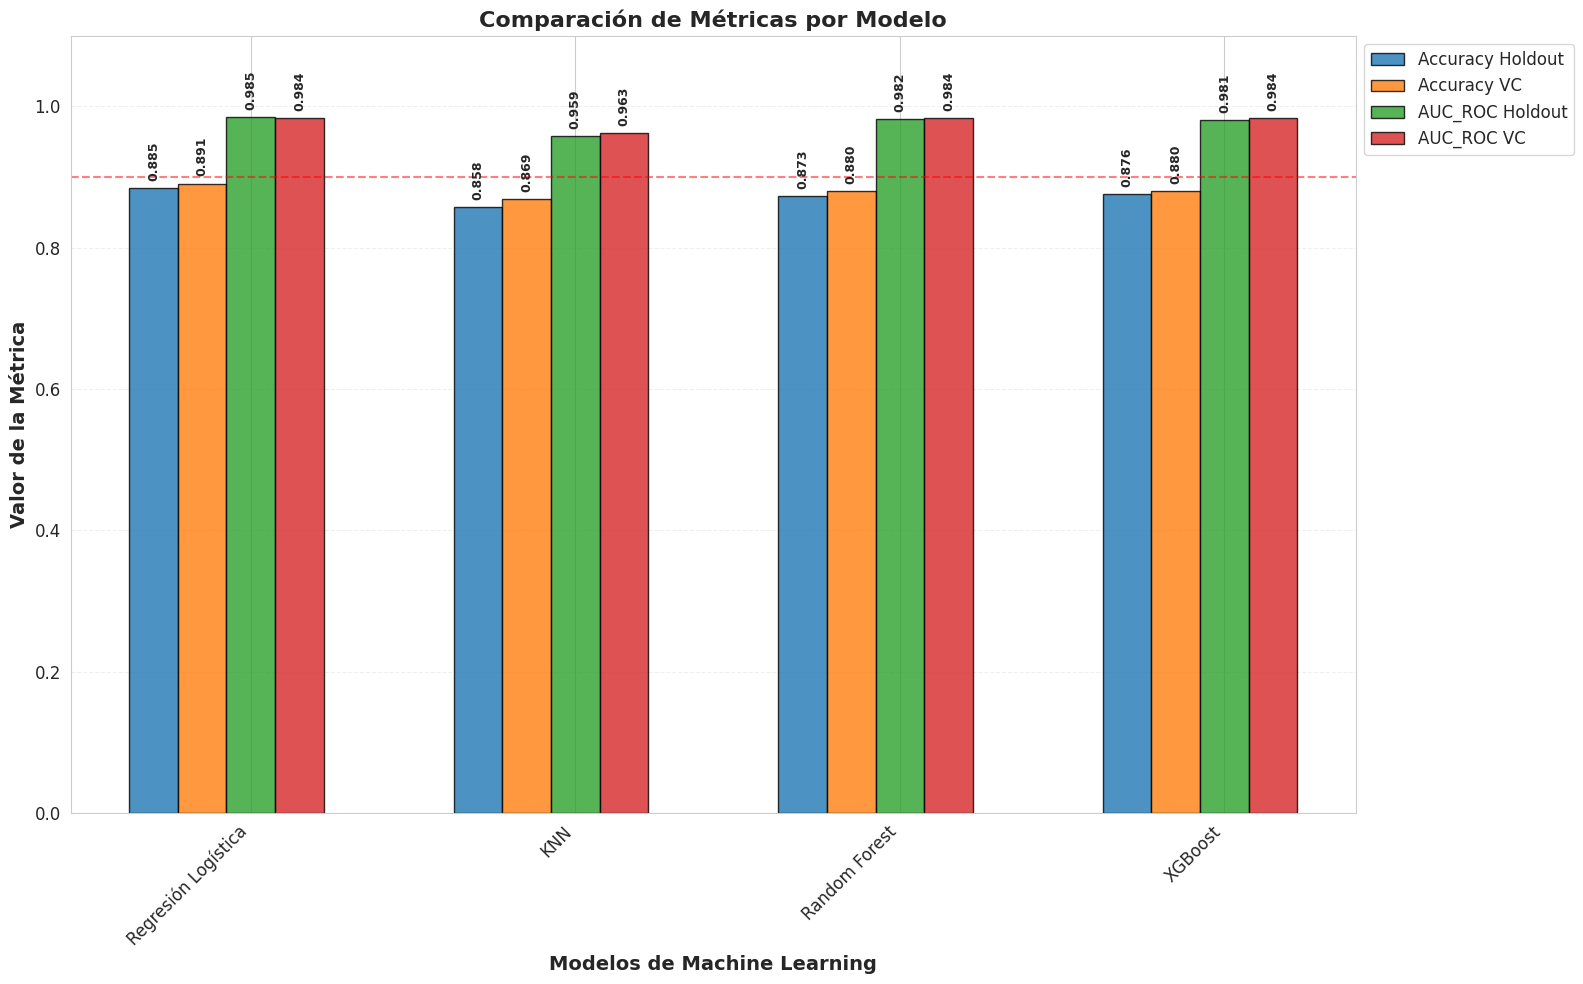

In [ ]:
#Grafica resumen de las metricas de los resultados
resultados_reales = {
    'Modelo': ['Regresión Logística', 'KNN',
               'Random Forest', 'XGBoost'],

    'Accuracy Holdout': [
        accuracy_rl_h, accuracy_knn_h,
        accuracy_rf_h, accuracy_xgb_h
    ],

    'Accuracy VC': [
        accuracy_rl_vc, accuracy_knn_vc,
        accuracy_rf_vc, accuracy_xgb_vc
    ],

    'AUC_ROC Holdout': [
        auc_rl_ovr_h, auc_knn_ovr_h,
        auc_rf_ovr_h, auc_xgb_ovr_h
    ],

    'AUC_ROC VC': [
        auc_rl_ovr_vc, auc_knn_ovr_vc,
        auc_rf_ovr_vc, auc_xgb_ovr_vc
    ],

}

df_resultados = pd.DataFrame(resultados_reales)

# Crear el gráfico de barras comparativo
plt.figure(figsize=(16, 10))

# Configurar los datos
modelos = df_resultados['Modelo']
metricas = ['Accuracy Holdout', 'Accuracy VC', 'AUC_ROC Holdout', 'AUC_ROC VC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Colores distintos para cada métrica

# Posiciones de las barras
x = np.arange(len(modelos))
width = 0.15  # Ancho de las barras

# Crear las barras para cada métrica
for i, metrica in enumerate(metricas):
    valores = df_resultados[metrica]
    plt.bar(x + i*width, valores, width, label=metrica, color=colors[i], alpha=0.8, edgecolor='black')

# Personalizar el gráfico
plt.xlabel('Modelos de Machine Learning', fontsize=14, fontweight='bold')
plt.ylabel('Valor de la Métrica', fontsize=14, fontweight='bold')
plt.title('Comparación de Métricas por Modelo', fontsize=16, fontweight='bold')
plt.xticks(x + width*2, modelos, rotation=45, ha='right', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, modelo in enumerate(modelos):
    for j, metrica in enumerate(metricas):
        valor = df_resultados[metrica].iloc[i]
        plt.text(i + j*width, valor + 0.01, f'{valor:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                rotation=90)

# Mejorar el layout
plt.tight_layout()
plt.ylim(0, 1.1)  # Ajustar el límite Y ya que las métricas van de 0 a 1

# Añadir una línea de referencia en 0.8 (buen performance)
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Umbral de buen performance (0.9)')

plt.show()